# BirdCLEF 2026 — Exploratory Data Analysis
Systematic EDA covering:
1. Dataset overview & missing values
2. Class distribution & imbalance
3. Taxonomic group breakdown
4. Audio quality (rating)
5. Geographic distribution
6. Secondary labels / co-occurrence
7. Audio duration analysis
8. Mel spectrogram samples
9. Correlation analysis
10. Feature relevance summary

In [ ]:
# # At the top of the Colab notebook, mount Drive if needed:
# from google.colab import drive
# drive.mount('/content/drive')

# ### NOTE #####
# # Uncomment to Mount Google Drive (permissions needed)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Imports & Paths

In [35]:
import os, warnings
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")

BASE        = Path("/content/drive/MyDrive/Kaggle/birdclef-2026")
TRAIN_AUDIO             = BASE / "train_audio"
TRAIN_SOUNDSCAPES       = BASE / "train_soundscapes"
TRAIN_SOUNDSCAPE_LABELS = BASE / "train_soundscapes_labels.csv"
TRAIN_META              = BASE / "train.csv"
TAXONOMY                = BASE / "taxonomy.csv"
SAMPLE_SUB              = BASE / "sample_submission.csv"

## 1. Dataset Overview

In [36]:
meta = pd.read_csv(TRAIN_META)
tax  = pd.read_csv(TAXONOMY)
sub  = pd.read_csv(SAMPLE_SUB)

print("Shape:", meta.shape)
print("\nColumn dtypes:")
print(meta.dtypes)
meta.head(5)

Shape: (35549, 15)

Column dtypes:
primary_label        object
secondary_labels     object
type                 object
latitude            float64
longitude           float64
scientific_name      object
common_name          object
class_name           object
inat_taxon_id         int64
author               object
license              object
rating              float64
url                  object
filename             object
collection           object
dtype: object


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [37]:
tax.head(5)

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


In [38]:
sub.head(5)

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


In [39]:
print("Missing values:")
missing = meta.isnull().sum()
print(missing[missing > 0] if missing.any() else "None")

n_species      = meta["scientific_name"].nunique()
n_species_tax      = tax["scientific_name"].nunique()
scored_species = sub.columns[1:]

print(f"\nTotal training files : {len(meta)}")
print(f"Unique primary labels: {n_species}")
print(f"Unique recorded species: {n_species_tax}")
print(f"Scored species       : {len(scored_species)}")
if "class_name" in tax.columns:
    print(f"Taxonomic classes    : {tax['class_name'].nunique()}")

# print("All species in train file :", meta["scientific_name"].unique(), " with ", len(meta["scientific_name"].unique()), " species" )
# print("All species in taxonomy file :", tax["scientific_name"].unique(), " with ", len(tax["scientific_name"].unique()), " species" )
# print("All species in sub file :", sub["scientific_name"].unique(), " with ", len(sub["scientific_name"].unique()), " species" )
print("Missing species :", list(set(tax["scientific_name"].unique()) - set(meta["scientific_name"].unique()))  ) 
missing_in_tax = list(set(tax["primary_label"].unique()) - set(scored_species.to_list()))
print("Missing species ", len(missing_in_tax), " species : ", missing_in_tax )

Missing values:
None

Total training files : 35549
Unique primary labels: 206
Unique recorded species: 234
Scored species       : 234
Taxonomic classes    : 5
Missing species : ['Insect son02', 'Insect son21', 'Insect son15', 'Insect son07', 'Insect son03', 'Insect son20', 'Insect son18', 'Adenomera guarani', 'Insect son22', 'Insect son19', 'Insect son24', 'Insect son04', 'Insect son17', 'Insect son16', 'Insect son06', 'Insect son13', 'Insect son12', 'Insect son01', 'Insect son09', 'Insect son25', 'Pithecopus azureus', 'Insect son08', 'Insect son05', 'Insect son14', 'Insect son10', 'Chiasmocleis mehelyi', 'Insect son23', 'Insect son11']
Missing species  0  species :  []


## 2. Class Distribution & Imbalance

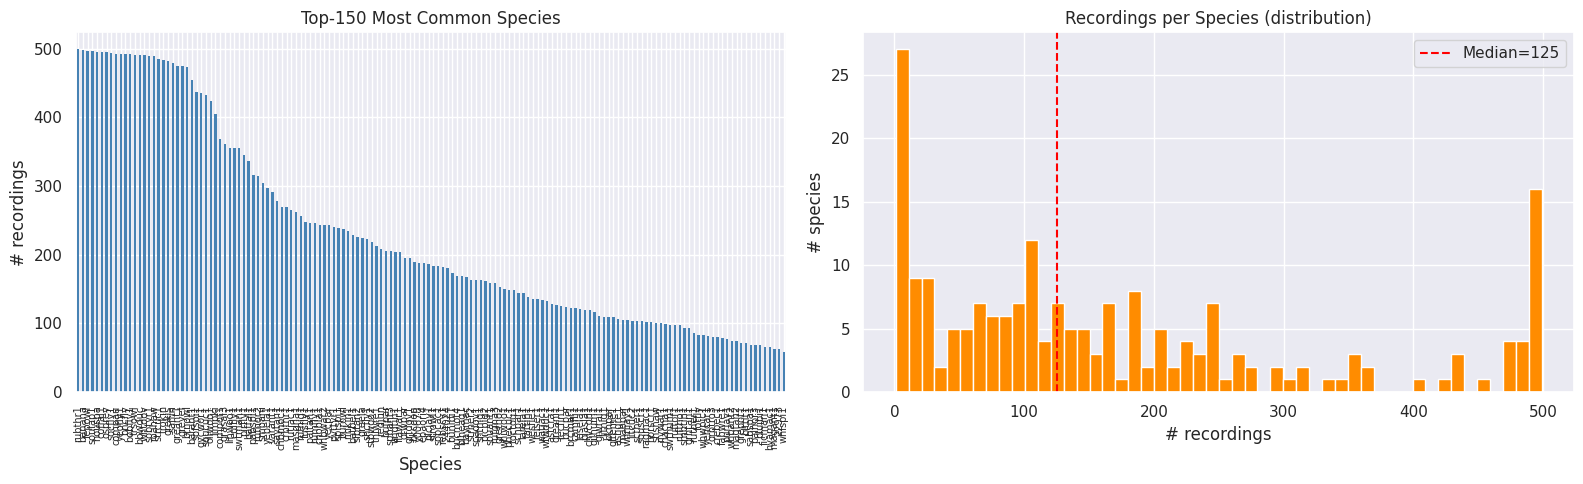

Min: 1 | Max: 499 | Median: 125
Species with < 5 recordings : 14
Species with > 50 recordings: 154


In [40]:
counts = meta["primary_label"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

counts.head(150).plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set(title="Top-150 Most Common Species", xlabel="Species", ylabel="# recordings")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)

axes[1].hist(counts.values, bins=50, color="darkorange", edgecolor="white")
axes[1].set(title="Recordings per Species (distribution)", xlabel="# recordings", ylabel="# species")
axes[1].axvline(counts.median(), color="red", linestyle="--", label=f"Median={counts.median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Min: {counts.min()} | Max: {counts.max()} | Median: {counts.median():.0f}")
print(f"Species with < 5 recordings : {(counts < 5).sum()}")
print(f"Species with > 50 recordings: {(counts > 50).sum()}")

## 3. Taxonomic Group Breakdown

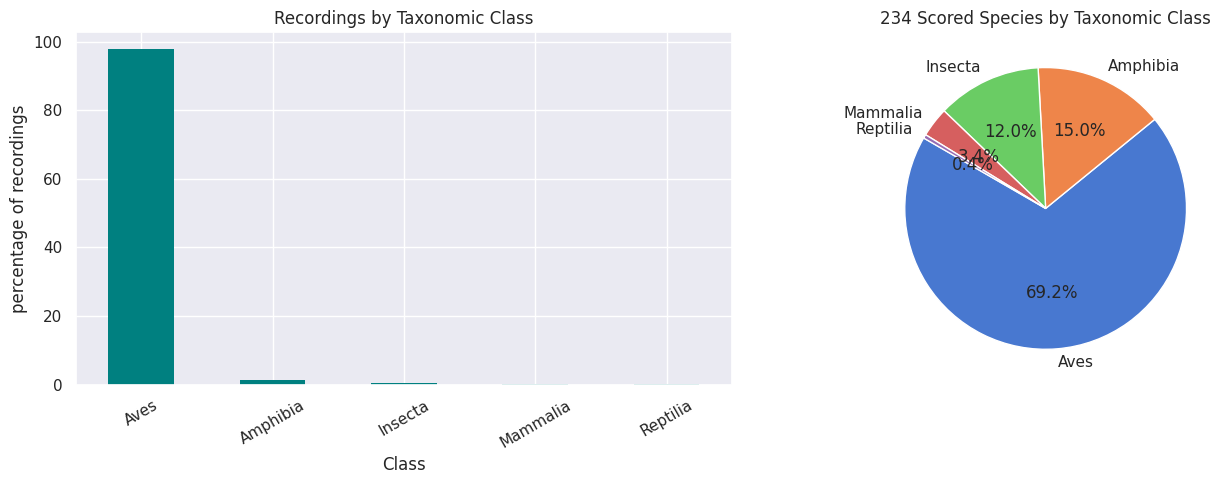

Class breakdown:
class_name
Aves        34799
Amphibia      451
Insecta       199
Mammalia       99
Reptilia        1
Name: count, dtype: int64


In [41]:
# if "class_name" in tax.columns and "primary_label" in tax.columns:
#     meta_tax = meta.merge(
#         tax[["primary_label", "scientific_name", "class_name"]],
#         on="primary_label", how="left")

species = (meta["primary_label"].value_counts()/len(meta))*100
animal_class = (meta["class_name"].value_counts()/len(meta))*100
count_class = (meta["class_name"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

animal_class.plot(kind="bar", ax=axes[0], color="teal", edgecolor="none")
axes[0].set(title="Recordings by Taxonomic Class", xlabel="Class", ylabel="percentage of recordings")
axes[0].tick_params(axis="x", rotation=30)

# axes[1].hist(count_class, bins=1000, color="darkorange", edgecolor="white")
# axes[1].set(title="Recordings per Class (distribution)", xlabel="percentage of recordings", ylabel="Classes present")
# axes[1].axvline(count_class.median(), color="red", linestyle="--", label=f"Median={count_class.median():.0f}")
# axes[1].legend()

# species.head(150).plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="none")
# axes[1].set(title="Top-150 Most Common Species", xlabel="Species", ylabel="percentage of recordings")
# axes[1].tick_params(axis="x", rotation=90, labelsize=7)

# plt.figure(figsize=(6,6))
tax["class_name"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=150)
axes[1].set(title="234 Scored Species by Taxonomic Class", xlabel="", ylabel="")

plt.tight_layout()
plt.show()

print("Class breakdown:")
print(meta["class_name"].value_counts())


## 4. Audio Quality (Rating)

Ratings are 0–5 (xeno-canto community quality scores). Low-quality recordings may hurt training.

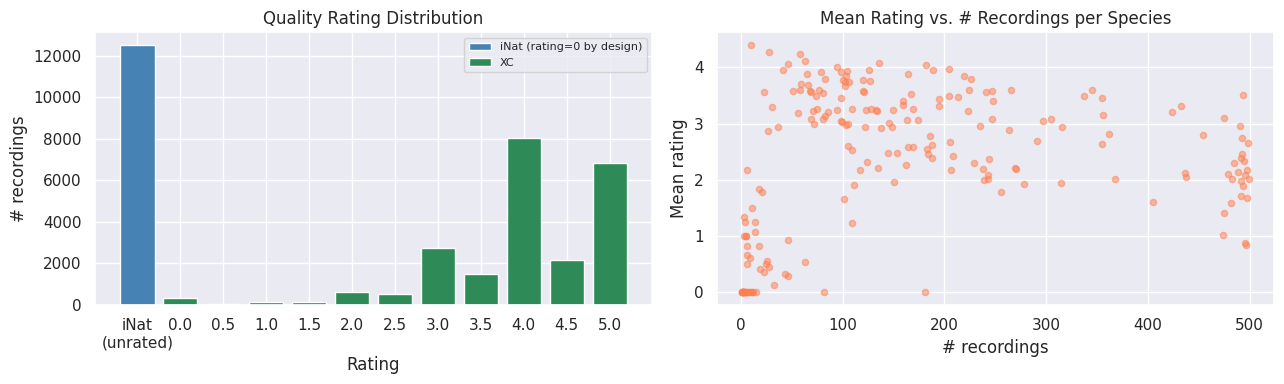

count    23043.00
mean         4.01
std          0.97
min          0.00
25%          3.50
50%          4.00
75%          5.00
max          5.00
Name: rating, dtype: float64

XC low quality (rating < 2): 632
Note: all iNat recordings have rating=0 by design — not low quality


In [42]:
if "rating" in meta.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Separate iNat (rating=0 by design) from XC rated recordings
    if "collection" in meta.columns:
        xc   = meta[meta["collection"] == "XC"]
        inat = meta[meta["collection"] == "iNat"]
        xc_rating_counts = xc["rating"].value_counts().sort_index()
        ax = axes[0]
        ax.bar(["iNat\n(unrated)"], [len(inat)], color="steelblue", label="iNat (rating=0 by design)")
        ax.bar(xc_rating_counts.index.astype(str), xc_rating_counts.values,
               color="seagreen", edgecolor="white", label="XC")
        ax.set(title="Quality Rating Distribution", xlabel="Rating", ylabel="# recordings")
        ax.legend(fontsize=8)
    else:
        meta["rating"].value_counts().sort_index().plot(
            kind="bar", ax=axes[0], color="seagreen", edgecolor="white")
        axes[0].set(title="Quality Rating Distribution", xlabel="Rating (0-5)", ylabel="# recordings")

    rating_by_species = (meta.groupby("primary_label")["rating"].mean()
                         .reset_index()
                         .rename(columns={"rating": "mean_rating"})
                         .merge(counts.reset_index().rename(columns={"count": "n_recs"}),
                                on="primary_label"))
    axes[1].scatter(rating_by_species["n_recs"], rating_by_species["mean_rating"],
                    alpha=0.5, s=20, color="coral")
    axes[1].set(title="Mean Rating vs. # Recordings per Species",
                xlabel="# recordings", ylabel="Mean rating")

    plt.tight_layout()
    plt.show()

    print(meta[meta["collection"] == "XC"]["rating"].describe().round(2) if "collection" in meta.columns else meta["rating"].describe().round(2))
    low = (meta[meta.get("collection", pd.Series(["XC"]*len(meta))) == "XC"]["rating"] < 2).sum() if "collection" in meta.columns else (meta["rating"] < 2).sum()
    print(f"\nXC low quality (rating < 2): {low}")
    print("Note: all iNat recordings have rating=0 by design — not low quality")
else:
    print("No rating column found")

## 5. Geographic Distribution

Useful for building geo-priors in post-processing (species range filtering).

Recordings with coordinates: 35549 / 35549


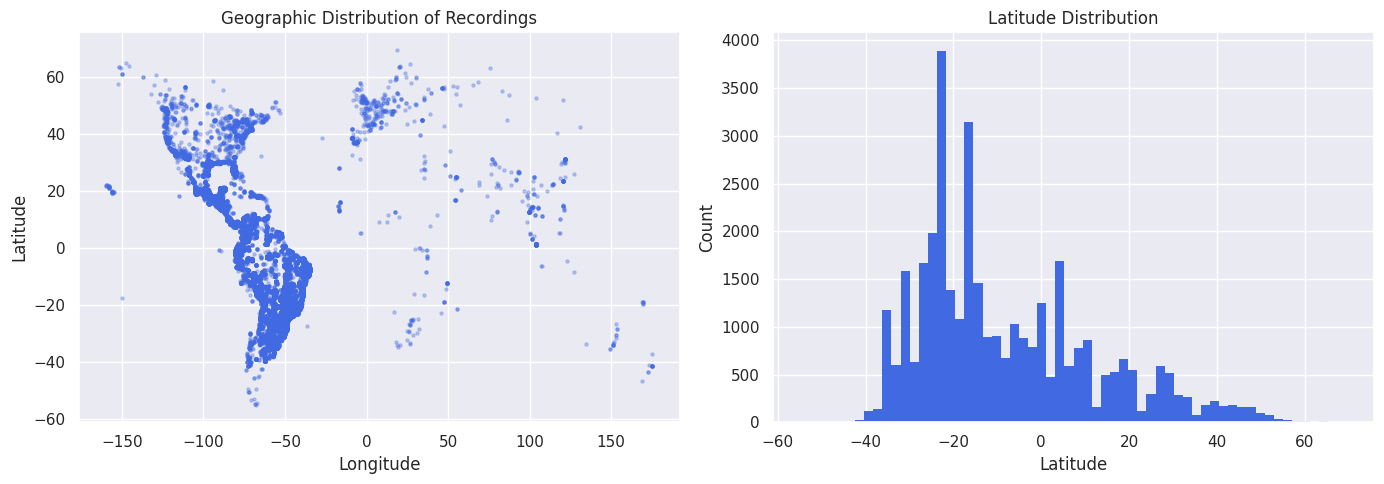

Lat range: -54.8574 → 69.578
Lon range: -159.6556 → 175.3239


In [43]:
if {"latitude", "longitude"}.issubset(meta.columns):
    valid_geo = meta.dropna(subset=["latitude", "longitude"])
    print(f"Recordings with coordinates: {len(valid_geo)} / {len(meta)}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(valid_geo["longitude"], valid_geo["latitude"],
                    alpha=0.3, s=5, c="royalblue")
    axes[0].set(title="Geographic Distribution of Recordings",
                xlabel="Longitude", ylabel="Latitude")

    axes[1].hist(valid_geo["latitude"], bins=60, color="royalblue", edgecolor="none")
    axes[1].set(title="Latitude Distribution", xlabel="Latitude", ylabel="Count")

    plt.tight_layout()
    plt.show()

    print("Lat range:", valid_geo["latitude"].min(), "→", valid_geo["latitude"].max())
    print("Lon range:", valid_geo["longitude"].min(), "→", valid_geo["longitude"].max())
else:
    print("No lat/lon columns found")

## 6. Secondary Labels (Co-occurrence)

Secondary labels = other species audible in the same recording. Key for multi-label soft training.

Recordings with secondary labels: 4372 (12.3%)


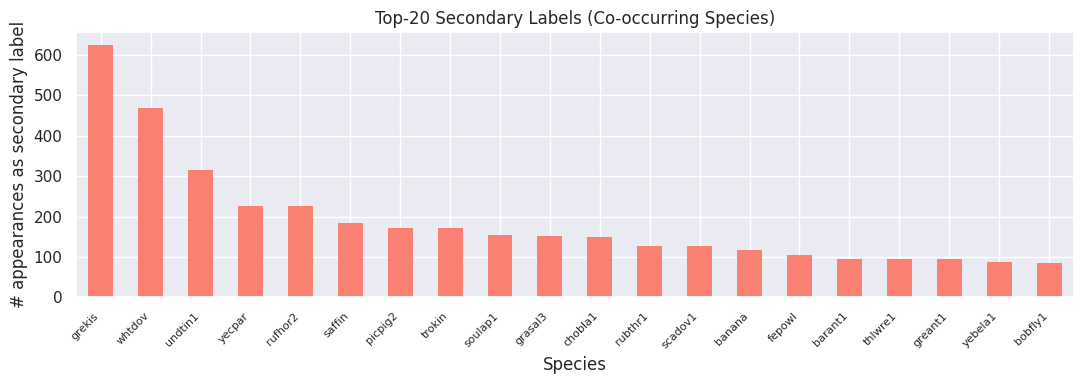

In [44]:
if "secondary_labels" in meta.columns:
    sec = meta["secondary_labels"].fillna("[]").apply(
        lambda x: eval(x) if isinstance(x, str) else x)
    has_secondary = sec.apply(lambda x: len(x) > 0 if isinstance(x, list) else False)
    print(f"Recordings with secondary labels: {has_secondary.sum()} ({100*has_secondary.mean():.1f}%)")

    all_secondary = [sp for sublist in sec for sp in (sublist if isinstance(sublist, list) else [])]
    top_cooccur = pd.Series(Counter(all_secondary)).sort_values(ascending=False).head(20)

    plt.figure(figsize=(11, 4))
    top_cooccur.plot(kind="bar", color="salmon", edgecolor="none")
    plt.title("Top-20 Secondary Labels (Co-occurring Species)")
    plt.xlabel("Species"); plt.ylabel("# appearances as secondary label")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No secondary_labels column found")

## 7. Audio Duration Analysis

All test windows are 5s. Training files vary — need padding (short) or chunking (long).

n=300 | min=0.0s | max=266.5s | mean=32.4s | median=22.9s
Recordings < 5s : 22
Recordings > 60s: 45


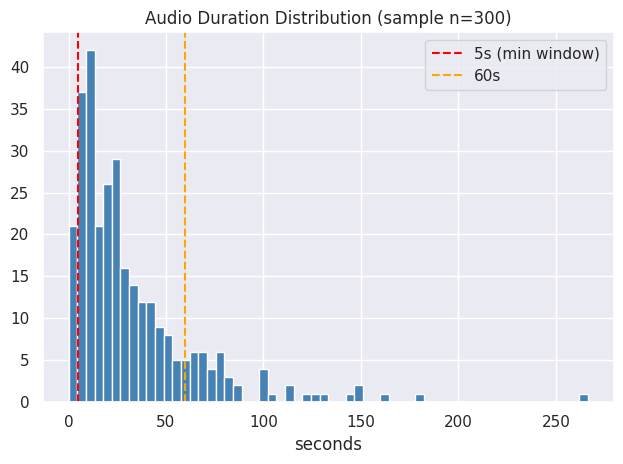

In [45]:
sample_files = list(TRAIN_AUDIO.rglob("*.ogg"))[:300]
durations = []
for fp in sample_files:
    try:
        durations.append(librosa.get_duration(path=str(fp)))
    except Exception:
        pass

durations = np.array(durations)
print(f"n={len(durations)} | min={durations.min():.1f}s | max={durations.max():.1f}s | "
      f"mean={durations.mean():.1f}s | median={np.median(durations):.1f}s")
print(f"Recordings < 5s : {(durations < 5).sum()}")
print(f"Recordings > 60s: {(durations > 60).sum()}")

# plt.figure(figsize=(10, 4))
plt.hist(durations, bins=60, color="steelblue", edgecolor="white")
plt.axvline(5,  color="red",    linestyle="--", label="5s (min window)")
plt.axvline(60, color="orange", linestyle="--", label="60s")
plt.title("Audio Duration Distribution (sample n=300)")
plt.xlabel("seconds"); plt.legend(); plt.tight_layout(); plt.show()

## 8. Mel Spectrogram Samples

Visual sanity check — clean calls vs noisy backgrounds.

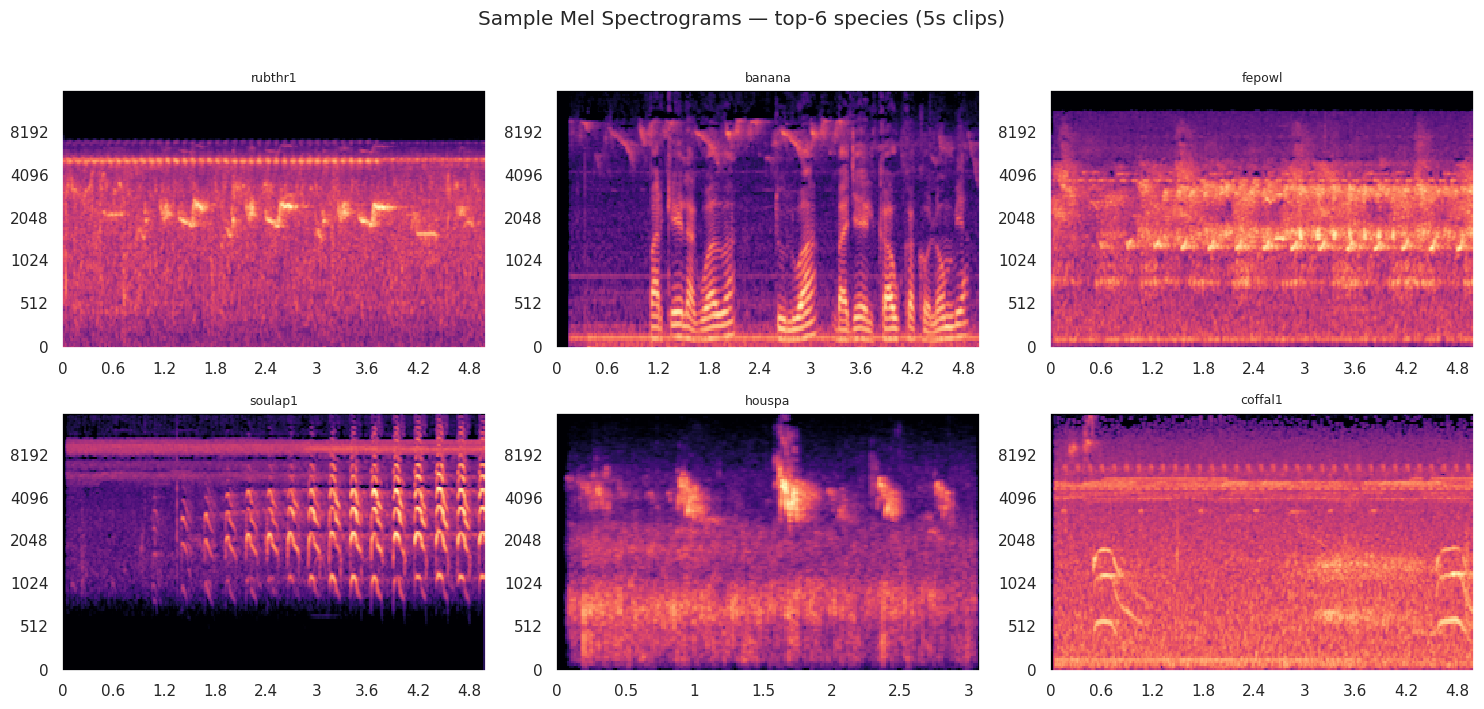

In [46]:
SR, N_MELS, HOP = 32000, 128, 512
sample_species = meta["primary_label"].value_counts().index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, sp in zip(axes.flat, sample_species):
    files = list((TRAIN_AUDIO / sp).glob("*.ogg"))
    if not files:
        ax.set_title(f"{sp} (no file)"); continue
    y, sr = librosa.load(str(files[0]), sr=SR, duration=5.0)
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=HOP), ref=np.max)
    librosa.display.specshow(mel, sr=sr, hop_length=HOP,
                             x_axis="time", y_axis="mel", ax=ax)
    ax.set_title(sp, fontsize=9); ax.set_xlabel(""); ax.set_ylabel("")

plt.suptitle("Sample Mel Spectrograms — top-6 species (5s clips)", y=1.01)
plt.tight_layout(); plt.show()

## 9. Train Soundscapes & Missing Species

In [47]:
soundscape_labels = pd.read_csv(TRAIN_SOUNDSCAPE_LABELS)
print("Shape:", soundscape_labels.shape)
soundscape_labels.head(8)


Shape: (1478, 4)


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380
5,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:25,00:00:30,22961;23158;24321;517063;65380
6,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:30,00:00:35,22961;23158;24321;517063;65380
7,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:35,00:00:40,22961;23158;24321;517063;65380


In [48]:
soundscape_species = set(
    sp for labels in soundscape_labels["primary_label"]
    for sp in str(labels).split(";")
)
train_audio_species = set(meta["primary_label"].unique())
scored_species      = set(sub.columns[1:])

only_in_soundscapes = list(soundscape_species & scored_species - train_audio_species)
missing_entirely    = list(scored_species - train_audio_species - soundscape_species)

print(f"\nUnique species in soundscape labels        : {len(soundscape_species)}")
print(f"Scored species only in train_soundscapes   : {len(only_in_soundscapes)}")
print(f"Scored species missing from ALL training   : {len(missing_entirely)}")
print(f"All species in training data : {len(only_in_soundscapes) + n_species}")
print(f"All species with taxonomic data : {n_species_tax}")
if only_in_soundscapes:
    print("\nSpecies only in soundscapes (need this data!):", only_in_soundscapes)


Unique species in soundscape labels        : 75
Scored species only in train_soundscapes   : 28
Scored species missing from ALL training   : 0
All species in training data : 234
All species with taxonomic data : 234

Species only in soundscapes (need this data!): ['47158son02', '25073', '47158son20', '47158son16', '47158son01', '47158son08', '47158son11', '47158son13', '517063', '1491113', '47158son07', '47158son21', '47158son03', '47158son22', '47158son06', '47158son23', '47158son15', '47158son14', '47158son12', '47158son05', '47158son24', '47158son25', '47158son17', '47158son18', '47158son19', '47158son10', '47158son09', '47158son04']


In [49]:
import re

non_birds  = tax[tax["class_name"] != "Aves"]
sonotypes  = tax[tax["primary_label"].str.match(r"^\d+son\d+$", na=False)]

print(f"Non-bird scored species : {len(non_birds)}")
print(non_birds["class_name"].value_counts())
print(f"\nSonotype entries        : {len(sonotypes)}")
print(sonotypes[["primary_label","class_name"]].head(5))



Non-bird scored species : 72
class_name
Amphibia    35
Insecta     28
Mammalia     8
Reptilia     1
Name: count, dtype: int64

Sonotype entries        : 25
   primary_label class_name
30    47158son01    Insecta
31    47158son02    Insecta
32    47158son03    Insecta
33    47158son04    Insecta
34    47158son05    Insecta


## 9. Correlation Analysis

Checking relationships between numeric metadata features.

Numeric columns: ['latitude', 'longitude', 'inat_taxon_id', 'rating']


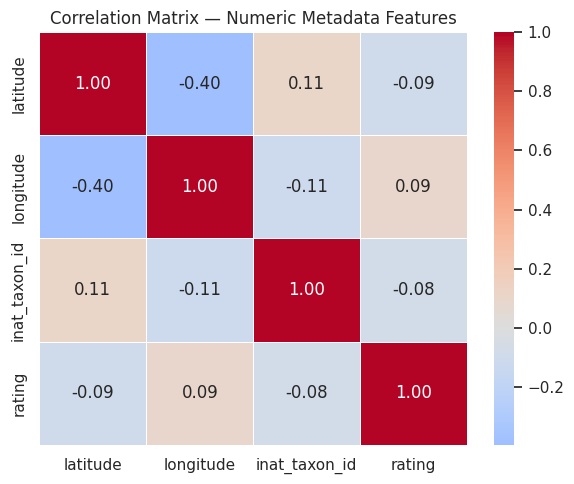

               latitude  longitude  inat_taxon_id  rating
latitude          1.000     -0.396          0.108  -0.093
longitude        -0.396      1.000         -0.113   0.092
inat_taxon_id     0.108     -0.113          1.000  -0.084
rating           -0.093      0.092         -0.084   1.000


In [50]:
numeric_cols = meta.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

if len(numeric_cols) >= 2:
    corr = meta[numeric_cols].corr()
    plt.figure(figsize=(max(6, len(numeric_cols)), max(5, len(numeric_cols)-1)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
    plt.title("Correlation Matrix — Numeric Metadata Features")
    plt.tight_layout(); plt.show()
    print(corr.round(3))
else:
    print("Not enough numeric columns for correlation")

## 10. Feature Relevance Summary

In [51]:
summary = {
    "Feature": [
        "audio waveform → mel spectrogram",
        "primary_label",
        "secondary_labels",
        "rating",
        "latitude / longitude",
        "date / month",
        "class_name (taxonomy)",
        "author / license / url",
        "filename",
        "collection (xeno-canto vs iNat)",
    ],
    "Use": [
        "PRIMARY model input (image CNN)",
        "PRIMARY training target",
        "Soft multi-label training targets",
        "Sample weighting / quality filtering (drop < 2.0)",
        "Geo-prior post-processing (species range)",
        "Temporal prior (migratory species)",
        "Stratified splits / grouped evaluation",
        "Not useful for modeling",
        "File I/O only",
        "May indicate label noise level",
    ],
    "Priority": [
        "🔴 Critical",
        "🔴 Critical",
        "🟠 High",
        "🟠 High",
        "🟡 Medium (post-proc)",
        "🟡 Medium (post-proc)",
        "🟢 Low",
        "⚪ None",
        "⚪ None",
        "🟢 Low",
    ]
}

pd.DataFrame(summary).style.set_properties(**{"text-align": "left"})

,Feature,Use,Priority
0,audio waveform → mel spectrogram,PRIMARY model input (image CNN),🔴 Critical
1,primary_label,PRIMARY training target,🔴 Critical
2,secondary_labels,Soft multi-label training targets,🟠 High
3,rating,Sample weighting / quality filtering (drop < 2.0),🟠 High
4,latitude / longitude,Geo-prior post-processing (species range),🟡 Medium (post-proc)
5,date / month,Temporal prior (migratory species),🟡 Medium (post-proc)
6,class_name (taxonomy),Stratified splits / grouped evaluation,🟢 Low
7,author / license / url,Not useful for modeling,⚪ None
8,filename,File I/O only,⚪ None
9,collection (xeno-canto vs iNat),May indicate label noise level,🟢 Low
